In [2]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#check to make sure the data dir is correct
import os
os.listdir('/content/drive/MyDrive')
os.listdir('/content/drive/MyDrive/imitation_learning_training/pick_and_place_imitation_data')[:5]

['Pick_place_episode_16.hdf5',
 'Pick_place_episode_100.hdf5',
 'Pick_place_episode_19.hdf5',
 'Pick_place_episode_18.hdf5',
 'Pick_place_episode_15.hdf5']

In [11]:
#Install dependencies
!pip install h5py torch numpy matplotlib -q

In [12]:
# Imports & Config
import os, glob, h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# ── update these two paths to match your Google Drive layout ──
DATA_DIR   = '/content/drive/MyDrive/imitation_learning_training/pick_and_place_imitation_data'
SAVE_DIR   = '/content/drive/MyDrive/imitation_learning_training/bc_checkpoints'

OBS_DIM    = 17     # 6 joint pos + 7 ee pose + 3 cube pos + 1 gripper
ACTION_DIM = 6      # target joint angles
BATCH_SIZE = 256
EPOCHS     = 200
LR         = 1e-3
HIDDEN_DIM = 256
VAL_SPLIT  = 0.1    # 10% held out for validation
SEED       = 42

os.makedirs(SAVE_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [13]:
# Dataset
class PickPlaceDataset(Dataset):
    """
    Loads all (observation, action) pairs from the HDF5 episodes.

    Observation (dim=17):
        joint_positions   (6)  — current arm configuration in radians
        end_effector_pose (7)  — EE position (3) + quaternion (4)
        cube_position     (3)  — cube XYZ in metres
        gripper_state     (1)  — finger joint value (open~0.79, closed~1.14)

    Action (dim=6):
        target joint angles at t+1 — what the expert did next
    """
    def __init__(self, data_dir):
        pattern = os.path.join(data_dir, 'Pick_place_episode_*.hdf5')
        files   = sorted(
            glob.glob(pattern),
            key=lambda x: int(os.path.basename(x).split('_')[-1].replace('.hdf5', ''))
        )
        if not files:
            raise FileNotFoundError(f'No HDF5 files found at: {pattern}')

        obs_list, act_list = [], []
        for fpath in files:
            with h5py.File(fpath, 'r') as f:
                jp   = f['joint_positions'][:]    # (T, 6)
                ac   = f['actions'][:]            # (T, 6)
                cube = f['cube_position'][:]      # (T, 3)
                ee   = f['end_effector_pose'][:]  # (T, 7)
                grip = f['gripper_state'][:]      # (T,)

            obs = np.concatenate([jp, ee, cube, grip[:, None]], axis=1)  # (T, 17)
            obs_list.append(obs)
            act_list.append(ac)

        self.obs     = torch.tensor(np.concatenate(obs_list), dtype=torch.float32)
        self.actions = torch.tensor(np.concatenate(act_list), dtype=torch.float32)

        print(f'Loaded {len(files)} episodes — {len(self.obs):,} total timesteps')
        print(f'Obs shape: {self.obs.shape}  |  Action shape: {self.actions.shape}')

    def __len__(self):          return len(self.obs)
    def __getitem__(self, idx): return self.obs[idx], self.actions[idx]

In [14]:
# Split & Normalise
dataset = PickPlaceDataset(DATA_DIR)

n_val   = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# compute normalisation stats from training data only
train_obs = dataset.obs[train_ds.indices]
obs_mean  = train_obs.mean(0);  obs_std = train_obs.std(0) + 1e-8

train_act = dataset.actions[train_ds.indices]
act_mean  = train_act.mean(0);  act_std = train_act.std(0) + 1e-8

# normalise in-place
dataset.obs     = (dataset.obs     - obs_mean) / obs_std
dataset.actions = (dataset.actions - act_mean) / act_std

# save stats — needed at inference time in CoppeliaSim
np.save(f'{SAVE_DIR}/obs_mean.npy', obs_mean.numpy())
np.save(f'{SAVE_DIR}/obs_std.npy',  obs_std.numpy())
np.save(f'{SAVE_DIR}/act_mean.npy', act_mean.numpy())
np.save(f'{SAVE_DIR}/act_std.npy',  act_std.numpy())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {n_train:,} samples  |  Val: {n_val:,} samples')

Loaded 100 episodes — 10,014 total timesteps
Obs shape: torch.Size([10014, 17])  |  Action shape: torch.Size([10014, 6])
Train: 9,013 samples  |  Val: 1,001 samples


In [15]:
# Model
class BCPolicy(nn.Module):
    """
    3-layer MLP with LayerNorm + Dropout.
    obs (17) → action (6)
    """
    def __init__(self, obs_dim=OBS_DIM, action_dim=ACTION_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),

            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, obs):
        return self.net(obs)


model = BCPolicy().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Parameters: 105,350
BCPolicy(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [16]:
# Training Loop
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):

    # train
    model.train()
    batch_losses = []
    for obs, act in train_loader:
        obs, act = obs.to(DEVICE), act.to(DEVICE)
        loss = criterion(model(obs), act)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    # validate
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for obs, act in val_loader:
            obs, act = obs.to(DEVICE), act.to(DEVICE)
            val_batch_losses.append(criterion(model(obs), act).item())

    train_loss = np.mean(batch_losses)
    val_loss   = np.mean(val_batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    # save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':             epoch,
            'model_state_dict':  model.state_dict(),
            'val_loss':          val_loss,
            'obs_dim':           OBS_DIM,
            'action_dim':        ACTION_DIM,
            'hidden_dim':        HIDDEN_DIM,
        }, f'{SAVE_DIR}/bc_best.pth')

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'train={train_loss:.6f} | '
              f'val={val_loss:.6f} | '
              f'best_val={best_val_loss:.6f}')

print(f'\nDone. Best val loss: {best_val_loss:.6f}')

Epoch   1/200 | train=0.124101 | val=0.014118 | best_val=0.014118
Epoch  20/200 | train=0.004108 | val=0.001883 | best_val=0.001753
Epoch  40/200 | train=0.003153 | val=0.001839 | best_val=0.001451
Epoch  60/200 | train=0.002766 | val=0.001790 | best_val=0.001362
Epoch  80/200 | train=0.002467 | val=0.001369 | best_val=0.001362
Epoch 100/200 | train=0.002160 | val=0.001351 | best_val=0.001267
Epoch 120/200 | train=0.001942 | val=0.001279 | best_val=0.001148
Epoch 140/200 | train=0.001796 | val=0.001226 | best_val=0.001120
Epoch 160/200 | train=0.001758 | val=0.001216 | best_val=0.001120
Epoch 180/200 | train=0.001618 | val=0.001169 | best_val=0.001092
Epoch 200/200 | train=0.001608 | val=0.001119 | best_val=0.001092

Done. Best val loss: 0.001092


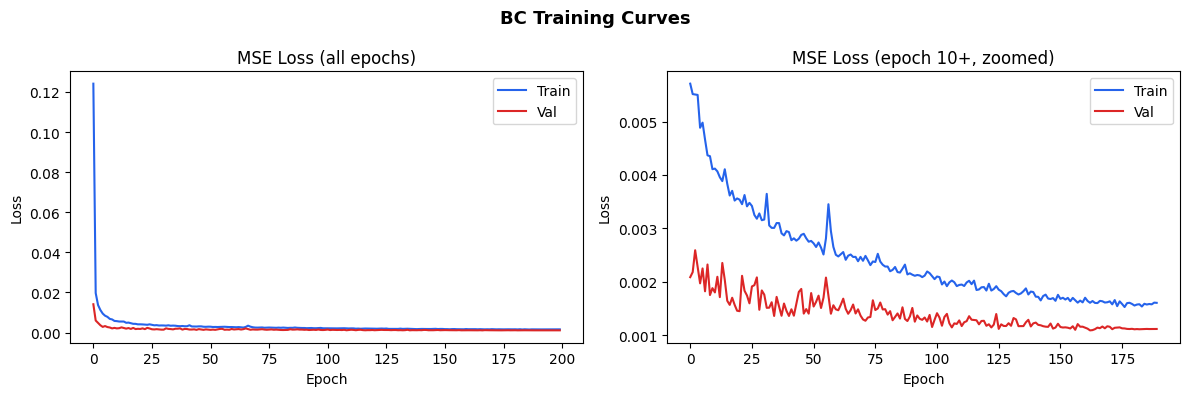

In [17]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('BC Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(train_losses, label='Train', color='#2563EB')
axes[0].plot(val_losses,   label='Val',   color='#DC2626')
axes[0].set_title('MSE Loss (all epochs)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_losses[10:], label='Train', color='#2563EB')
axes[1].plot(val_losses[10:],   label='Val',   color='#DC2626')
axes[1].set_title('MSE Loss (epoch 10+, zoomed)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/bc_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

In [19]:
# Evaluate on Val Set
ckpt = torch.load(
    f'{SAVE_DIR}/bc_best.pth',
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Best checkpoint — epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.6f}")

act_mean_t = torch.tensor(act_mean).to(DEVICE)
act_std_t  = torch.tensor(act_std).to(DEVICE)

all_pred, all_true = [], []
with torch.no_grad():
    for obs, act in val_loader:
        pred        = model(obs.to(DEVICE))
        pred_denorm = pred * act_std_t + act_mean_t
        act_denorm  = act.to(DEVICE) * act_std_t + act_mean_t
        all_pred.append(pred_denorm.cpu().numpy())
        all_true.append(act_denorm.cpu().numpy())

pred_np = np.concatenate(all_pred)
true_np = np.concatenate(all_true)

mae_per_joint = np.abs(pred_np - true_np).mean(axis=0)
print('\nMAE per joint (val set):')
for j, mae in enumerate(mae_per_joint):
    print(f'  Joint {j}: {mae:.5f} rad  ({np.degrees(mae):.3f}°)')
print(f'\nOverall MAE: {mae_per_joint.mean():.5f} rad  ({np.degrees(mae_per_joint.mean()):.3f}°)')

Best checkpoint — epoch 173  val_loss=0.001092


/tmp/ipykernel_1149/2038098462.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  act_mean_t = torch.tensor(act_mean).to(DEVICE)
/tmp/ipykernel_1149/2038098462.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  act_std_t  = torch.tensor(act_std).to(DEVICE)



MAE per joint (val set):
  Joint 0: 0.00718 rad  (0.412°)
  Joint 1: 0.00473 rad  (0.271°)
  Joint 2: 0.00528 rad  (0.302°)
  Joint 3: 0.00365 rad  (0.209°)
  Joint 4: 0.00368 rad  (0.211°)
  Joint 5: 0.00589 rad  (0.338°)

Overall MAE: 0.00507 rad  (0.290°)


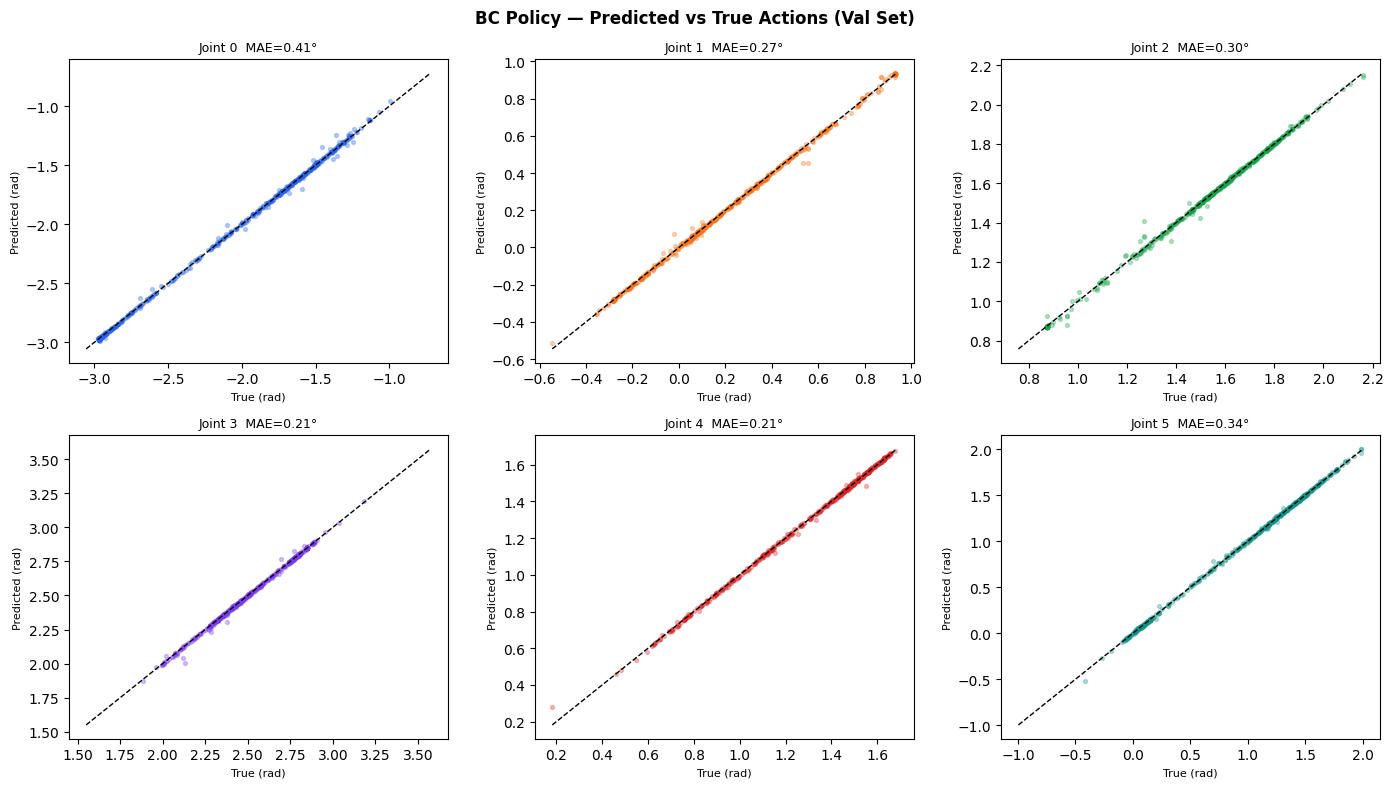

In [20]:
# Predicted vs True Scatter
JCOLS = ['#2563EB','#F97316','#16A34A','#7C3AED','#DC2626','#0D9488']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('BC Policy — Predicted vs True Actions (Val Set)', fontweight='bold')

for j, ax in enumerate(axes.flat):
    ax.scatter(true_np[:500, j], pred_np[:500, j],
               alpha=0.3, s=8, color=JCOLS[j])
    lo = min(true_np[:, j].min(), pred_np[:, j].min())
    hi = max(true_np[:, j].max(), pred_np[:, j].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='perfect')
    ax.set_title(f'Joint {j}  MAE={np.degrees(mae_per_joint[j]):.2f}°', fontsize=9)
    ax.set_xlabel('True (rad)', fontsize=8)
    ax.set_ylabel('Predicted (rad)', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/bc_pred_vs_true.png', dpi=130, bbox_inches='tight')
plt.show()

In [21]:
# What to download from Drive
print('\nFiles to download from Drive for CoppeliaSim inference:')
for fname in ['bc_best.pth','obs_mean.npy','obs_std.npy','act_mean.npy','act_std.npy']:
    print(f'  {SAVE_DIR}/{fname}')


Files to download from Drive for CoppeliaSim inference:
  /content/drive/MyDrive/imitation_learning_training/bc_checkpoints/bc_best.pth
  /content/drive/MyDrive/imitation_learning_training/bc_checkpoints/obs_mean.npy
  /content/drive/MyDrive/imitation_learning_training/bc_checkpoints/obs_std.npy
  /content/drive/MyDrive/imitation_learning_training/bc_checkpoints/act_mean.npy
  /content/drive/MyDrive/imitation_learning_training/bc_checkpoints/act_std.npy
